In [112]:
## Library
import xarray as xr
import matplotlib.pyplot as plt
import glob
import numpy as np
from glob import glob
from itertools import compress
from matplotlib.dates import DateFormatter
import matplotlib.dates as mdates
import pandas as pd


In [113]:
### DP SCREAM DATA
files_in = glob("/data/project/ARM_Summer_School_2026/data/modeling/dpscream/scream_dpxx_LASSO_SGP_*.fullfield.AVERAGE.nhours_x1.*.nc")
ds_dp_scream = xr.open_mfdataset(files_in, combine='nested', concat_dim = 'date')

In [114]:
### LASSO DATA
files = glob("/data/project/ARM_Summer_School_2026/data/modeling/lasso/*/sgplassodiagconfobsmod*/obs_model/sgplassodiagobsmod*C1.m1*.nc") # drop z ones 
in_paths = list(compress(files , [('modz' not in f) and ('5C1' not in f) for f in files]))

ds_all = xr.open_mfdataset(in_paths, combine='nested', concat_dim = 'date')

In [115]:
### OBS
file = glob("/data/archive/sgp/sgpsondewnpnC1.b1/sgpsondewnpnC1.b1.20260520.232458.nc")
ds= xr.open_mfdataset(file)



In [116]:
### OBS
SW_PATH = '/data/archive/sgp/sgpqcrad1longE13.c2/'

CASE_DATES = [20180709,
              20190517,
              20190929]

# SW_FILENAME = 'sgpqcrad1longE13.c2.20180709.000000.cdf'
SW_FILENAMES = [f'sgpqcrad1longE13.c2.{date}.000000.cdf' for date in CASE_DATES]

In [117]:
sw_dpscream_list = []
sw_lasso_list = []
for date in CASE_DATES:

    cur_day_fname = f'sgpqcrad1longE13.c2.{date}.000000.cdf'
    next_day_fname = f'sgpqcrad1longE13.c2.{date+1}.000000.cdf' # won;t work for end of month but these dates are convenient!
    sw_case = xr.open_mfdataset([SW_PATH+cur_day_fname, SW_PATH+next_day_fname]).BestEstimate_down_short_hemisp

    # now the case would start from 00:00UTC.

    # for DPSCREAM, data range is hourly from 13UTC to 3UTC the next day; temp res = 1h

    sw_case_dpscream = sw_case.isel(time=slice(13*60, (24+3+1)*60)).resample(time='1h').mean()
    sw_case_dpscream = sw_case_dpscream.assign_coords(time=sw_case_dpscream.time - pd.Timedelta(hours=6))
    sw_dpscream_list.append(sw_case_dpscream)


    # for LASSO, 06:00 - 21:00 local time UTC-6; temp res = 10min
    # so 12UTC to 27UTC (3UTC next day)
    sw_case_lasso = sw_case.isel(time=slice(12*60, (24+3+1)*60)).resample(time='10min').mean()
    sw_case_lasso = sw_case_lasso.assign_coords(time=sw_case_lasso.time - pd.Timedelta(hours=6))
    sw_lasso_list.append(sw_case_lasso)


sw_dpscream = xr.concat(
    sw_dpscream_list,
    dim='case'
)

sw_lasso = xr.concat(
    sw_lasso_list,
    dim='case'
)

    

# Cloud Fraction

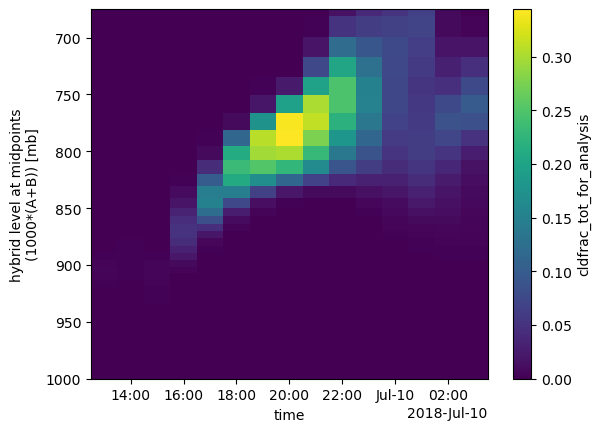

In [118]:
#ds_dp_scream.sel(date=0).cldfrac_tot_for_analysis.mean('ncol').where(ds_dp_scream.sel(date=0).mean('ncol').z_mid < 5000).plot(x='time')
ds_plot = (
    ds_dp_scream
    .sel(date=0)
    .sel(time=slice('2018-07-09T13:00:00',
                    '2018-07-10T03:00:00'))
)

cf = (
    ds_plot.cldfrac_tot_for_analysis
    .mean('ncol')
    .where(ds_plot.z_mid.mean('ncol') < 5000)
)

cf.plot(x='time')
plt.ylim(675,1000)
plt.gca().invert_yaxis()
#plt.show()

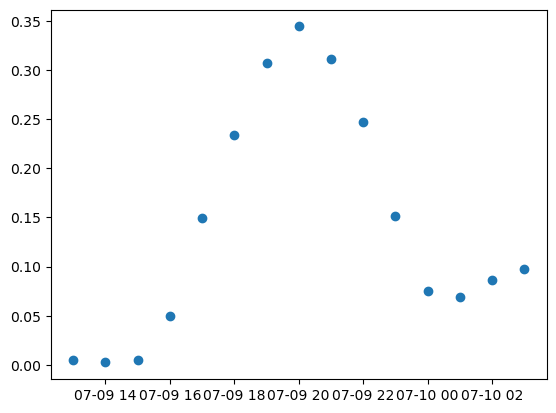

In [119]:
ds = ds_dp_scream.sel(date=0)

# Mean cloud fraction over ncol
cf_mean = ds.cldfrac_tot_for_analysis

# Keep only levels below 5000 m
cf_below5km = cf_mean.where(ds.z_mid < 5000)

# Plot vertical structure below 5 km
#cf_below5km.plot(x='time')

# Maximum cloud fraction below 5 km
max_cf_below5km = cf_below5km.mean('ncol').max(dim='lev')
plt.scatter(max_cf_below5km.time, max_cf_below5km.values)

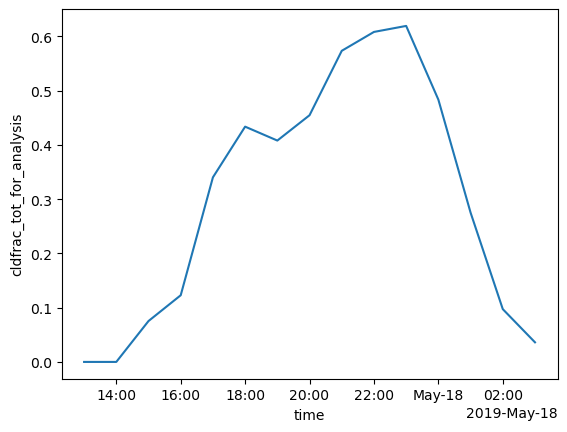

In [123]:
ds = ds_dp_scream.sel(date=1)

# Mean cloud fraction over ncol
cf_mean = ds.cldfrac_tot_for_analysis.mean('ncol')

# Keep only levels below 5000 m
cf_below5km = cf_mean.where(ds.z_mid.mean('ncol') < 5000)

# Plot vertical structure below 5 km
#cf_below5km.plot(x='time')

# Maximum cloud fraction below 5 km
max_cf_below5km = cf_below5km.max(dim='lev')
max_cf_below5km.plot(x='time')

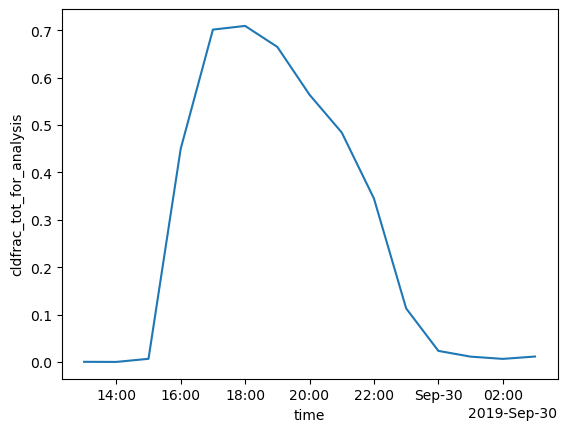

In [124]:
ds = ds_dp_scream.sel(date=2)
# Mean cloud fraction over ncol
cf_mean = ds.cldfrac_tot_for_analysis.mean('ncol')

# Keep only levels below 5000 m
cf_below5km = cf_mean.where(ds.z_mid.mean('ncol') < 5000)

# Plot vertical structure below 5 km
#cf_below5km.plot(x='time')

# Maximum cloud fraction below 5 km
max_cf_below5km = cf_below5km.max(dim='lev')
max_cf_below5km.plot(x='time')

# Radiation Flux

In [53]:
#ds_dp_scream.sel(date=0).SW_flux_dn_at_model_top.min(dim='ncol').plot()
ds_dp_scream_t = ds_dp_scream.assign_coords(time=ds_dp_scream.time - pd.Timedelta(hours=6))
#ds_dp_scream_t.append(ds_dp_scream_t)


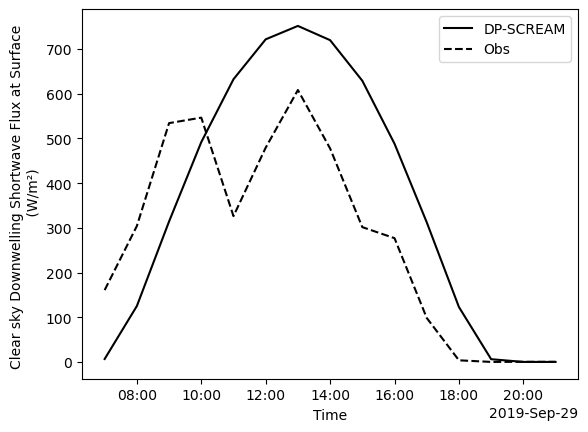

In [125]:

#ds_dp_scream_t.sel(date=0).SW_flux_dn_at_model_bot.min(dim='ncol').plot(label='min')
ds_dp_scream_t.sel(date=2).SW_clrsky_flux_dn_at_model_bot.max(dim='ncol').plot(color='black',label='DP-SCREAM')
#ds_dp_scream_t.sel(date=0).SW_flux_dn_at_model_bot.mean(dim='ncol').plot(label='mean')
sw_dpscream.isel(case=2).plot(color='black', linestyle='--',label='Obs')
plt.xlabel('Time')
plt.ylabel('Clear sky Downwelling Shortwave Flux at Surface \n (W/m²)')
plt.legend()

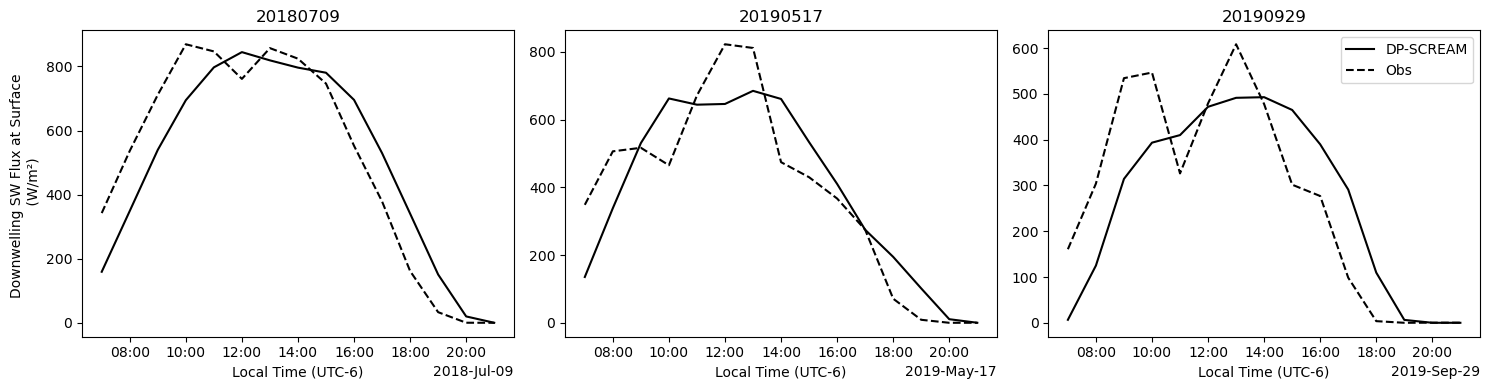

In [127]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, ax in enumerate(axes):

    ds_dp_scream_t.sel(date=i).SW_flux_dn_at_model_bot.max(dim='ncol').plot(
        ax=ax,
        color='black',
        label='DP-SCREAM'
    )

    sw_dpscream.isel(case=i).plot(
        ax=ax,
        color='black',
        linestyle='--',
        label='Obs'
    )

    #ax.set_title(f'Case {i+1}')
    ax.set_title(str(CASE_DATES[i]))
    ax.set_xlabel('Local Time (UTC-6)')

    if i == 0:
        ax.set_ylabel('Downwelling SW Flux at Surface \n (W/m²)')
    else:
        ax.set_ylabel('')

ax.legend().remove

    

plt.tight_layout()